In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from collections import Counter
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


#für Hierarchisches Clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [ ]:
#angepasst auf finale datei
df = pd.read_csv("naiver_ansatz/ab_ag_canonical_forms.csv")
regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
antigen_labels = df["antigen_name"].tolist()


In [7]:
def residue_percentage(sequence):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)
    
    #### Farbzuordnung vorbereiten
    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 2D
    fig, (ax_scatter, ax_legend) = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [ ]:
feature_spaces = {}
for region in regions: 
    fs_rows = []
    for df_row in df.itertuples():
        # Metadaten der PDB-Einträge
        pdb = df_row.pdb
        antigen_name = df_row.antigen_name
        antigen_species = df_row.antigen_species

        # AS-Häufigkeiten-Koordinaten der PDB-Einträge
        seq_as_str = getattr(df_row, region)
        seq_as_list = list(seq_as_str)
        residues_percentages = residue_percentage(seq_as_list)
        percentages = [pair[1] for pair in residues_percentages]

        # Längen-Koordinate der PDB-Einträge    
        seq_length = getattr(df_row, f"{region}_length")

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb] + [antigen_name] + [antigen_species] + [seq_length] + percentages
        fs_rows.append(fs_row)

    # Umwandeln des Feature-Space von einer Liste in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["seq_length"] + residues)
    
    # Z-Transformation der Sequenzlängen und der AS-Häufigkeiten
    columns_to_scale = ["seq_length"] + residues
    feature_space_z = feature_space.copy()
    feature_space_z[columns_to_scale] = scaler.fit_transform(feature_space[columns_to_scale])
    feature_spaces[region] = feature_space_z


In [ ]:

for region in regions: 
    feature_space_visualize = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    show_feature_space(feature_space_visualize, region, antigen_labels)


#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

In [ ]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for region in regions:
    feature_space_elbow = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


In [ ]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for region in regions:
    feature_space_kmeans = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_kmeans.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


In [16]:
#häufigkeiten in cf überprüfen
cf = ["CF_H1","CF_H2", "CF_L1", "CF_L2", "CF_L3"]
for col in cf:
    print(f"\nVerteilung der Canonical Forms in {col}:")
    print(df[col].value_counts())



Verteilung der Canonical Forms in CF_H1:
CF_H1
H1-7-A    496
H1-7-C    175
H1-9-A     43
H1-7-D     27
H1-9-B     18
H1-8-B     10
H1-8-A      6
H1-7-B      2
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_H2:
CF_H2
H2-6-A    254
H2-5-A    222
H2-6-B    195
H2-6-D     43
H2-6-C     35
H2-8-A     15
H2-6-E     13
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_L1:
CF_L1
L1-11-A       354
L1-14-A        95
L1-12-B        81
L1-16,17-A     64
L1-11-B        59
L1-13-A        43
L1-12-A        26
L1-14-C        21
L1-13-B        19
L1-15-A         9
L1-14-B         3
L1-10-A         2
L1-13-C         1
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_L2:
CF_L2
L2-7-A    777
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_L3:
CF_L3
L3-9,10-A     461
L3-10,11-A    112
L3-10-A        79
L3-9-A         53
L3-8-A         48
L3-11-A        11
L3-5-A         10
L3-10-B         3
Name: count, dtype: int64


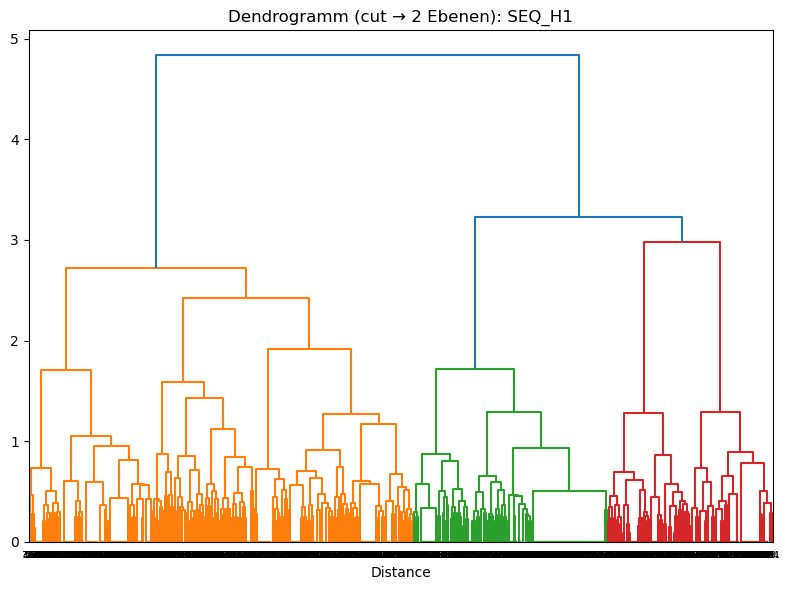


Teilbaum-Aufteilung für SEQ_H1 (cut auf 2 Ebenen → 3 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 102×
  spike protein s1: 73×
  hemagglutinin: 19×
  neuraminidase: 14×
  surface glycoprotein: 12×
  gametocyte surface protein p230: 11×
  fusion glycoprotein f0: 11×
  envelope glycoprotein e2: 9×
  clade a/e 93th057 hiv-1 gp120 core: 8×
  envelope glycoprotein gp160: 8×
  envelope glycoprotein gp120: 8×
  receptor tyrosine-protein kinase erbb-2: 7×
  ch848.10.17 gp120: 7×
  circumsporozoite protein: 7×
  envelope glycoprotein b: 6×
  leukocyte surface antigen cd47: 6×
  programmed cell death protein 1: 5×
  spike glycoprotein,fibritin: 4×
  ch848.10.17.sosip gp120: 4×
  tumor necrosis factor receptor superfamily member 5: 4×
  vascular endothelial growth factor a: 4×
  25 kda ookinete surface antigen: 4×
  reticulocyte binding protein 2b: 4×
  interleukin-17a: 4×
  envelope protein: 4×
  programmed cell death 1 ligand 1: 3×
  cytotoxic t-lymphocyte protein 4: 3×
  envelope protein e:

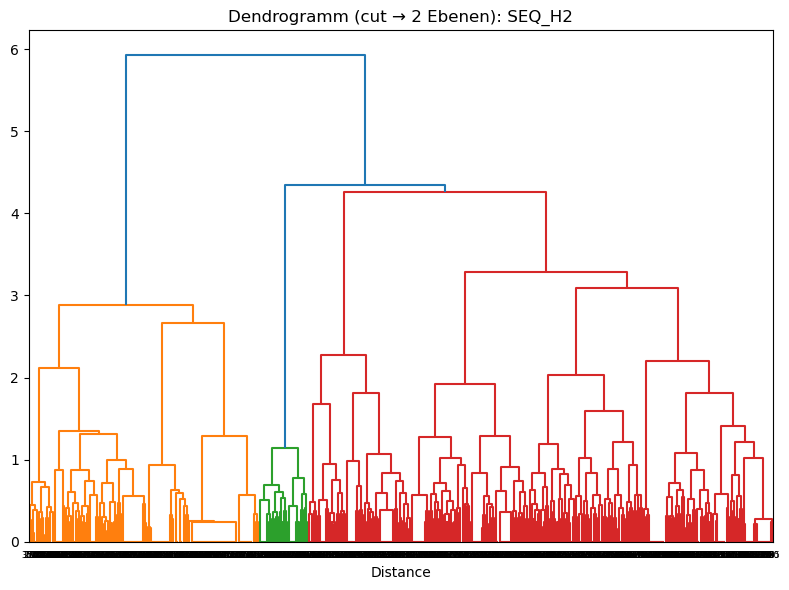


Teilbaum-Aufteilung für SEQ_H2 (cut auf 2 Ebenen → 3 Teilbäume):

Teilbaum 1:
  spike protein s1: 76×
  spike glycoprotein: 59×
  hemagglutinin: 20×
  surface glycoprotein: 12×
  circumsporozoite protein: 5×
  fusion glycoprotein f0: 5×
  histone chaperone asf1: 4×
  gametocyte surface protein p230: 4×
  neuraminidase: 4×
  nucleoprotein: 4×
  reticulocyte binding protein 2b: 3×
  programmed cell death protein 1: 3×
  reticulocyte-binding protein homolog 5: 3×
  epidermal growth factor receptor: 3×
  25 kda ookinete surface antigen: 3×
  tumor necrosis factor receptor superfamily member 5: 2×
  programmed cell death 1 ligand 1: 2×
  envelope protein: 2×
  envelope protein e: 2×
  spike glycoprotein,fibritin: 2×
  erythropoietin receptor: 2×
  genome polyprotein: 2×
  interleukin-17a: 2×
  tumor necrosis factor receptor superfamily member 9: 2×
  envelope glycoprotein e: 2×
  vascular endothelial growth factor a: 1×
  spike protein s2': 1×
  glycoprotein 120: 1×
  envelope glycoprotein

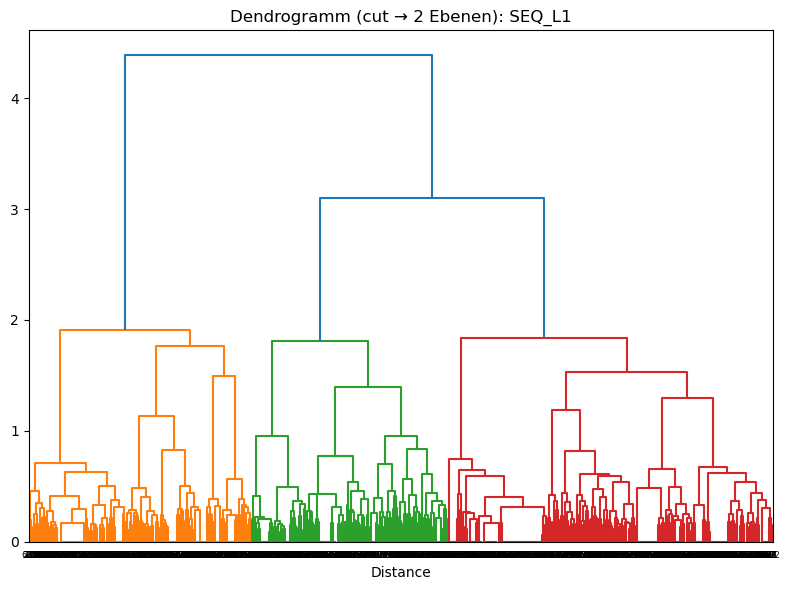


Teilbaum-Aufteilung für SEQ_L1 (cut auf 2 Ebenen → 3 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 69×
  spike protein s1: 55×
  hemagglutinin: 11×
  neuraminidase: 7×
  ch848.10.17 gp120: 7×
  envelope glycoprotein gp120: 6×
  fusion glycoprotein f0: 5×
  circumsporozoite protein: 5×
  reticulocyte binding protein 2b: 5×
  envelope glycoprotein b: 5×
  ch848.10.17.sosip gp120: 4×
  spike glycoprotein,fibritin: 4×
  surface glycoprotein: 4×
  envelope protein: 3×
  erythropoietin receptor: 3×
  sars-cov-2 spike glycoprotein: 3×
  hemagglutinin ha1 chain: 3×
  spike glycoprotein,fibritin,expression tag: 3×
  clade a/e 93th057 hiv-1 gp120 core: 2×
  25 kda ookinete surface antigen: 2×
  gametocyte surface protein p230: 2×
  epidermal growth factor receptor: 2×
  receptor tyrosine-protein kinase erbb-2: 2×
  hemagglutinin ha1: 2×
  nucleoprotein: 2×
  envelope glycoprotein e: 2×
  programmed cell death 1 ligand 1: 2×
  envelope protein e: 1×
  glycoprotein 120: 1×
  programmed cell deat

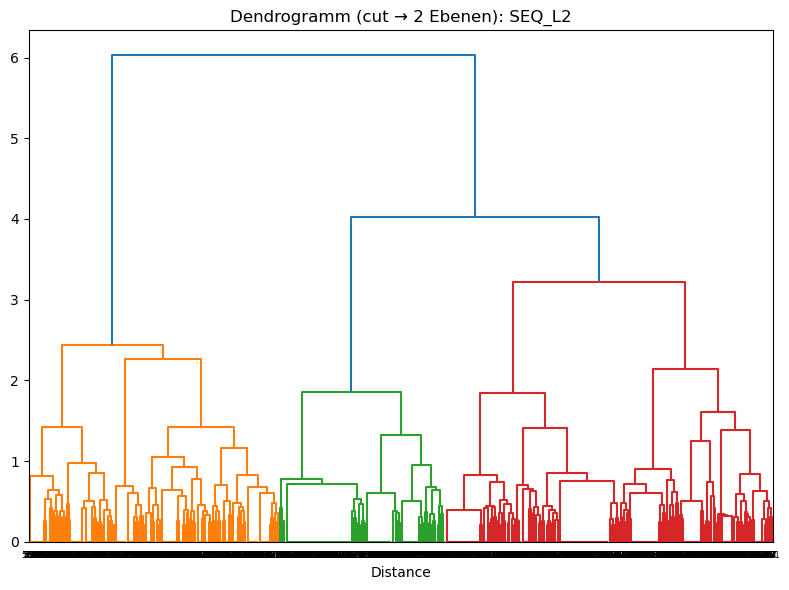


Teilbaum-Aufteilung für SEQ_L2 (cut auf 2 Ebenen → 3 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 70×
  spike protein s1: 59×
  hemagglutinin: 14×
  fusion glycoprotein f0: 10×
  ch848.10.17 gp120: 7×
  neuraminidase: 7×
  envelope glycoprotein gp120: 6×
  reticulocyte binding protein 2b: 6×
  surface glycoprotein: 5×
  circumsporozoite protein: 5×
  envelope glycoprotein b: 5×
  ch848.10.17.sosip gp120: 4×
  gametocyte surface protein p230: 4×
  spike glycoprotein,fibritin: 4×
  25 kda ookinete surface antigen: 4×
  interleukin-17a: 4×
  envelope glycoprotein gp160: 3×
  clade a/e 93th057 hiv-1 gp120 core: 3×
  hemagglutinin ha1 chain: 3×
  sars-cov-2 spike glycoprotein: 3×
  spike glycoprotein,fibritin,expression tag: 3×
  envelope protein: 3×
  nucleoprotein: 2×
  receptor tyrosine-protein kinase erbb-2: 2×
  envelope glycoprotein e2: 2×
  leukocyte surface antigen cd47: 2×
  envelope glycoprotein e: 2×
  erythropoietin receptor: 2×
  epidermal growth factor receptor: 2×
  hemagg

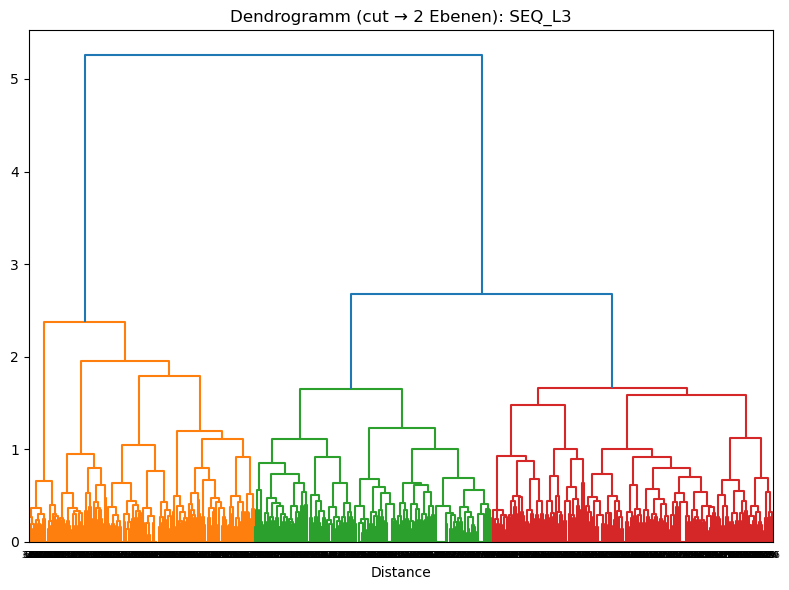


Teilbaum-Aufteilung für SEQ_L3 (cut auf 2 Ebenen → 3 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 67×
  spike protein s1: 56×
  hemagglutinin: 12×
  neuraminidase: 8×
  fusion glycoprotein f0: 8×
  ch848.10.17 gp120: 7×
  surface glycoprotein: 5×
  envelope glycoprotein gp120: 5×
  circumsporozoite protein: 5×
  reticulocyte binding protein 2b: 5×
  spike glycoprotein,fibritin: 4×
  ch848.10.17.sosip gp120: 4×
  envelope glycoprotein gp160: 4×
  envelope glycoprotein b: 4×
  hemagglutinin ha1 chain: 3×
  spike glycoprotein,fibritin,expression tag: 3×
  sars-cov-2 spike glycoprotein: 3×
  clade a/e 93th057 hiv-1 gp120 core: 3×
  programmed cell death 1 ligand 1: 3×
  envelope protein: 3×
  erythropoietin receptor: 3×
  receptor tyrosine-protein kinase erbb-2: 2×
  hemagglutinin ha1: 2×
  nucleoprotein: 2×
  25 kda ookinete surface antigen: 2×
  envelope glycoprotein e: 2×
  gametocyte surface protein p230: 2×
  envelope glycoprotein e2: 1×
  tumor necrosis factor ligand superfamily m

In [26]:
# Hierarchisches Clustering und Identifikation der farbigen Teilbäume



# CDR-Spalten & Antigen-Spalte
#cdr_columns = ['CDR_H1','CDR_H2','CDR_H3','CDR_L1','CDR_L2','CDR_L3']
#antigen_col = "antigen_name"

# Wie viele Fusionen vom Wurzelknoten wir runterscrollen wollen
levels_down = 2   # z.B. 2 Ebenen, so haben wir 3 teilbäume. das macht für H1 am meisten sinn

# Daten einlesen & unvollständige Zeilen entfernen
# zweite Zeile überflüssig, wenn Marcel data clean up korrekt gemacht hat
#df = pd.read_csv("data/df.tsv", sep='\t')
#df = df.dropna(subset=regions + [antigen_col]).reset_index(drop=True)


# AA-Häufigkeitsvektor-Funktion (20 Standard-AAs)
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
def aa_freq_vector(seq: str) -> np.ndarray:   #aa_freq_vector name der Funktion, nimmt eine sequenz, die string sein soll, rückgabe ist np.ndarray (Vektor)
    L      = len(seq)                                                   # Sequenzlänge 
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)   # Häufigkeit jeder AS
    return counts / L                                                    # direkte Normierung



#Loop über jede CDR-Region
for cdr in regions:
    seqs = df[cdr].tolist() #alle sequenzen als strings
    X    = np.vstack([aa_freq_vector(s) for s in seqs]) #für jede Sequenz 20 dimensionaler Häufigkeitsvektor, als Matrix zusammengeführt

    # Linkage berechnen (Ward, euklidische Distanz)
    Z = linkage(X, method="ward", metric="euclidean") #erstellt aus feature matrix X die linkage Matrix Z
                #ward minimiert varianz innerhalb der Cluster bei jedem merge

    # Threshold-Distanz für levels_down Stufen
    threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0
            # Z.shape[0] ist Anzahl aller merge schritte (n-1 für sequenzen)
            # Z[-levels_down,2] Distanz des Merge_schrittes der Plätze von unten


    # Erzeuge das Dendrogramm im "no_plot"-Modus, um Farben der Blätter abzufragen
    ddata = dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,
        no_plot=True       # unterdrückt die Grafik, liefert aber in ddata alle nötigen Infos
    )

    # Verbindet Blatt indizes mit Farbe
    leaves           = ddata['leaves']            # Reihenfolge der Blatt-Indizes
    leaves_colors    = ddata['leaves_color_list'] # RGB-Farben pro Blatt, gemäß threshold
    leaf_color_map   = {leaf: col for leaf, col in zip(leaves, leaves_colors)}
                    # zip leaves verbindet blatt_indizes mit jeweiliger Farbe
                    # leaf: baut ein dict, indem der Blatt_index(leaves) und das entsprechende RGB-Farb-Tuple (col) ist

    

    #Hier nochmal genau den Code nachvollziehen
    # 10) Finde die eindeutigen Farben in der Reihenfolge ihres Auftretens
    unique_colors = [] #ist Liste aller verschieder RGB-Farben, die in Dendrogramm auftauchen
    for col in leaves_colors:
        if col not in unique_colors:
            unique_colors.append(col) #Lister aller verschiedenen Farben, wie sie auftauchen, in gleicher Reihenfolge

    


    #  Weise jeder Farbe eine Cluster-Nummer zu
    color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}
   
    # 12) Cluster-Zuordnung für jedes Blatt nach Farbe
    cluster_ids = {leaf: color_cluster_map[col] for leaf, col in leaf_color_map.items()}

    # 13) Plot des vollständigen Dendrogramms mit Farb-Schwellenwert
    plt.figure(figsize=(8, 6))
    dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,  # färbt die Haupt-Branches
        leaf_rotation=0,
        leaf_font_size=6
    )
    plt.title(f"Dendrogramm (cut → {levels_down} Ebenen): {cdr}")
    plt.xlabel("Distance")
    plt.tight_layout()
    plt.show()

    # 14) Ausgabe: für jeden farbigen Teilbaum die Antigen-Häufigkeiten
    print(f"\nTeilbaum-Aufteilung für {cdr} (cut auf {levels_down} Ebenen → {len(unique_colors)} Teilbäume):")
    for col in unique_colors:
        cid     = color_cluster_map[col]
        # alle Blätter, deren Farbe = col
        leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
        # Antigen-Namen der entsprechenden Zeilen
        #hits    = df.loc[leaves_in_cluster, antigen_labels]
        hits = df.loc[leaves_in_cluster, "antigen_name"]

        counts  = hits.value_counts()
        print(f"\nTeilbaum {cid}:")
        for antigen, cnt in counts.items():
            print(f"  {antigen}: {cnt}×")

     

In [18]:
# === Ziel: Cluster-Zugehörigkeit pro CDR + antigen_name in neuer CSV speichern ===

# 1. Leerer DataFrame mit Index = PDB_IDs
cluster_df = pd.DataFrame(index=df["PDB_ID"])  # df ist dein Original-DataFrame mit Sequenzen & Canonical Forms

# 2. Schleife über alle CDR-Regionen (z. B. SEQ_H1, SEQ_H2 …)
for cdr in regions:  # regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
    labels_for_cdr = cluster_assignments[cdr]  # Dictionary mit {PDB_ID: cluster_label}
    
    # 3. Cluster-Labels pro CDR-Spalte eintragen
    cluster_df[cdr] = cluster_df.index.map(labels_for_cdr)

# 4. Spalten sinnvoll benennen
cluster_df.columns = [f"Cluster_{cdr}" for cdr in regions]

# 5. Optional: antigen_name hinzufügen für spätere Gruppierungen oder Visualisierungen
# Voraussetzung: df hat Spalten "PDB_ID" und "antigen_name"
cluster_df["antigen_name"] = df.set_index("PDB_ID").loc[cluster_df.index, "antigen_name"]

# 6. Als CSV-Datei exportieren (z. B. zur Verwendung in V-Measure)
cluster_df.to_csv("hierarchical_clusters_per_CDR.csv", index=True)

print("✅ Datei gespeichert als 'hierarchical_clusters_per_CDR.csv'")


NameError: name 'cluster_assignments' is not defined

In [ ]:

#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären
